#  Revenue Loss Analysis



## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

C_CANCEL   = "#dc2626"   # red
C_NOSHOW   = "#f59e0b"   # amber
C_CHECKOUT = "#2563eb"   # blue
C_GREEN    = "#16a34a"   # green
C_TOTAL    = "#7c3aed"   # purple
HEADER     = "#0D1B2A"
LIGHT      = "#F0F4F8"
SLATE      = "#475569"

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


In [2]:
TRAIN_PATH = r"C:\Venuki IIT\4th Sem\DSGP\Proj\Hotel-A-train_cleaned.CSV"
VAL_PATH   = r"C:\Venuki IIT\4th Sem\DSGP\Proj\Hotel-A-validation_cleaned.csv"

train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)

train["Reservation_Status"] = train["Reservation_Status"].replace({"Check-out": "Check-Out"})

val["Reservation_Status"] = val["Reservation_Status"].map(
    {1: "Check-Out", 2: "Canceled", 3: "No-Show"}
)

val = val.drop(
    columns=["Total_Revenue","ADR","booking_revenue","Checkin_Month",
             "Reservation_Label","Cancelled"],
    errors="ignore"
)


df = pd.concat([train, val[train.columns]], ignore_index=True)

df["Expected_checkin"] = pd.to_datetime(df["Expected_checkin"], errors="coerce")
df["Checkin_Month"]    = df["Expected_checkin"].dt.month

df["Actual_Room_Rate"] = df["Room_Rate"] * (1 - df["Discount_Rate"] / 100)
df["Revenue_At_Risk"]  = df["Actual_Room_Rate"] * df["Length_of_Stay"]

print(f"Total bookings loaded: {len(df):,}")
print(df["Reservation_Status"].value_counts())


Total bookings loaded: 30,248
Reservation_Status
Check-Out    22850
Canceled      4875
No-Show       2523
Name: count, dtype: int64


In [3]:
total_rev    = df["Revenue_At_Risk"].sum()
checkout_rev = df[df["Reservation_Status"]=="Check-Out"]["Revenue_At_Risk"].sum()
cancel_rev   = df[df["Reservation_Status"]=="Canceled"]["Revenue_At_Risk"].sum()
noshow_rev   = df[df["Reservation_Status"]=="No-Show"]["Revenue_At_Risk"].sum()
total_lost   = cancel_rev + noshow_rev
n_cancel     = (df["Reservation_Status"]=="Canceled").sum()
n_noshow     = (df["Reservation_Status"]=="No-Show").sum()
avg_cancel   = cancel_rev / n_cancel
avg_noshow   = noshow_rev / n_noshow

print(f"Total Potential Revenue  : ${total_rev:,.0f}")
print(f"Revenue Earned           : ${checkout_rev:,.0f}")
print(f"Lost to Cancellations    : ${cancel_rev:,.0f}")
print(f"Lost to No-Shows         : ${noshow_rev:,.0f}")
print(f"Total Revenue Lost       : ${total_lost:,.0f}")
print(f"Revenue Recovery Rate    : {checkout_rev/total_rev*100:.1f}%")
print(f"Avg Loss per Cancellation: ${avg_cancel:.0f}")
print(f"Avg Loss per No-Show     : ${avg_noshow:.0f}")


Total Potential Revenue  : $8,476,475
Revenue Earned           : $6,410,427
Lost to Cancellations    : $1,364,276
Lost to No-Shows         : $701,771
Total Revenue Lost       : $2,066,048
Revenue Recovery Rate    : 75.6%
Avg Loss per Cancellation: $280
Avg Loss per No-Show     : $278


## 2. KPI Summary



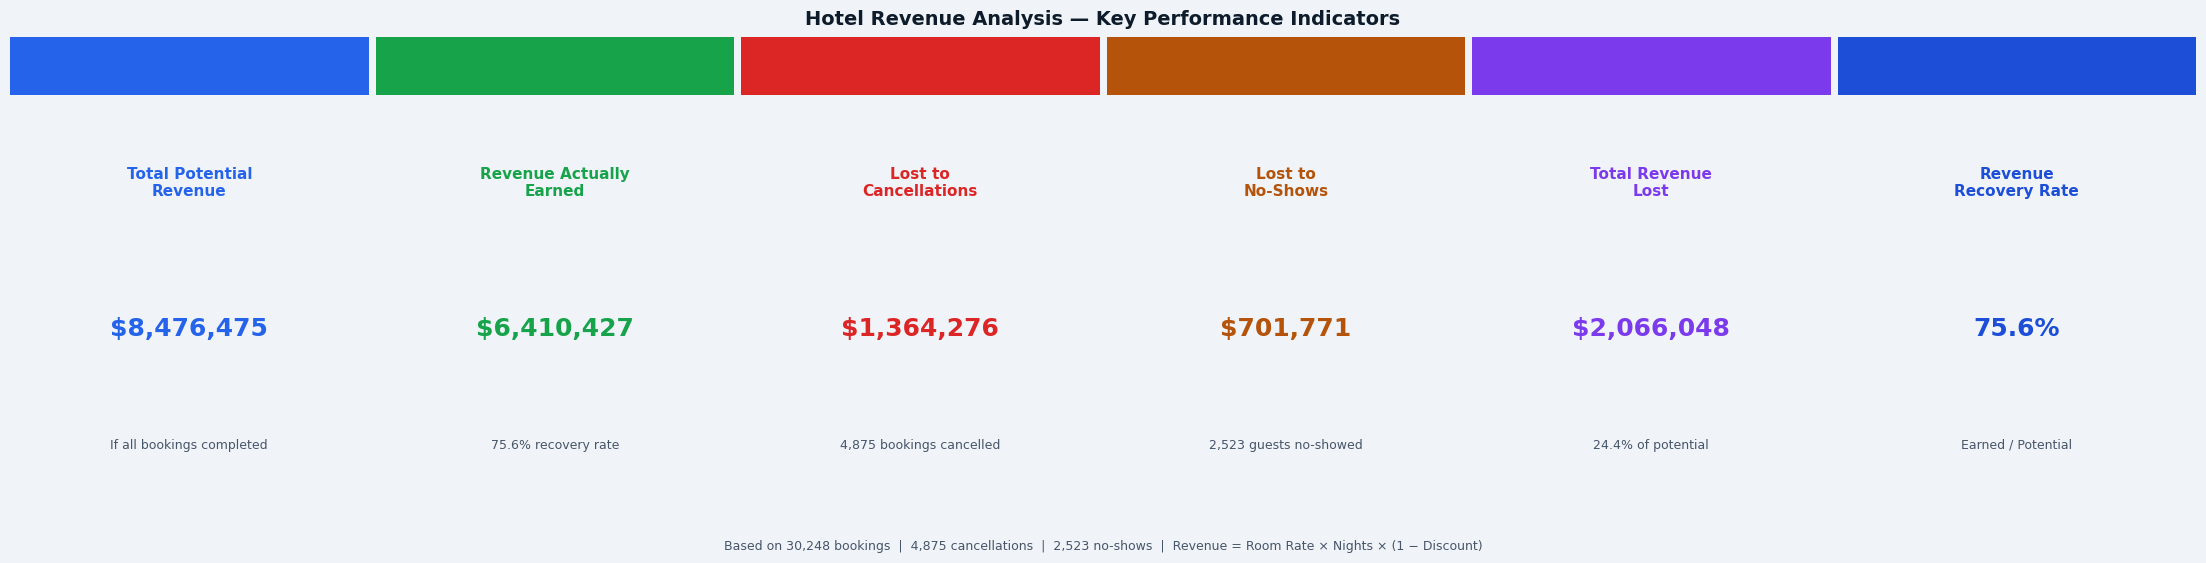

In [4]:
cards = [
    {"label":"Total Potential\nRevenue",  "value":f"${total_rev:,.0f}",    "sub":"If all bookings completed",              "bg":"#EFF6FF","fg":C_CHECKOUT},
    {"label":"Revenue Actually\nEarned",  "value":f"${checkout_rev:,.0f}", "sub":f"{checkout_rev/total_rev*100:.1f}% recovery rate","bg":"#F0FDF4","fg":C_GREEN},
    {"label":"Lost to\nCancellations",    "value":f"${cancel_rev:,.0f}",   "sub":f"{n_cancel:,} bookings cancelled",       "bg":"#FEF2F2","fg":C_CANCEL},
    {"label":"Lost to\nNo-Shows",         "value":f"${noshow_rev:,.0f}",   "sub":f"{n_noshow:,} guests no-showed",         "bg":"#FFFBEB","fg":"#B45309"},
    {"label":"Total Revenue\nLost",       "value":f"${total_lost:,.0f}",   "sub":f"{total_lost/total_rev*100:.1f}% of potential","bg":"#F5F3FF","fg":C_TOTAL},
    {"label":"Revenue\nRecovery Rate",    "value":f"{checkout_rev/total_rev*100:.1f}%","sub":"Earned / Potential",          "bg":"#EFF6FF","fg":"#1D4ED8"},
]

fig, axes = plt.subplots(1, 6, figsize=(22, 5))
fig.patch.set_facecolor(LIGHT)

for ax, card in zip(axes, cards):
    ax.set_facecolor(card["bg"]); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
    ax.add_patch(mpatches.Rectangle((0,0.88),1,0.12,transform=ax.transAxes,facecolor=card["fg"],clip_on=False))
    ax.text(0.5,0.70,card["label"],ha="center",va="center",fontsize=11,fontweight="bold",color=card["fg"],transform=ax.transAxes)
    ax.text(0.5,0.40,card["value"],ha="center",va="center",fontsize=18,fontweight="bold",color=card["fg"],transform=ax.transAxes)
    ax.text(0.5,0.16,card["sub"],ha="center",va="center",fontsize=9,color=SLATE,transform=ax.transAxes)

fig.text(0.5,1.01,"Hotel Revenue Analysis — Key Performance Indicators",ha="center",fontsize=14,fontweight="bold",color=HEADER)
fig.text(0.5,-0.04,f"Based on {len(df):,} bookings  |  {n_cancel:,} cancellations  |  {n_noshow:,} no-shows  |  Revenue = Room Rate × Nights × (1 − Discount)",ha="center",fontsize=9,color=SLATE)
plt.tight_layout(pad=0.5)
plt.show()


## 3. Cancellation vs No-Show Comparison




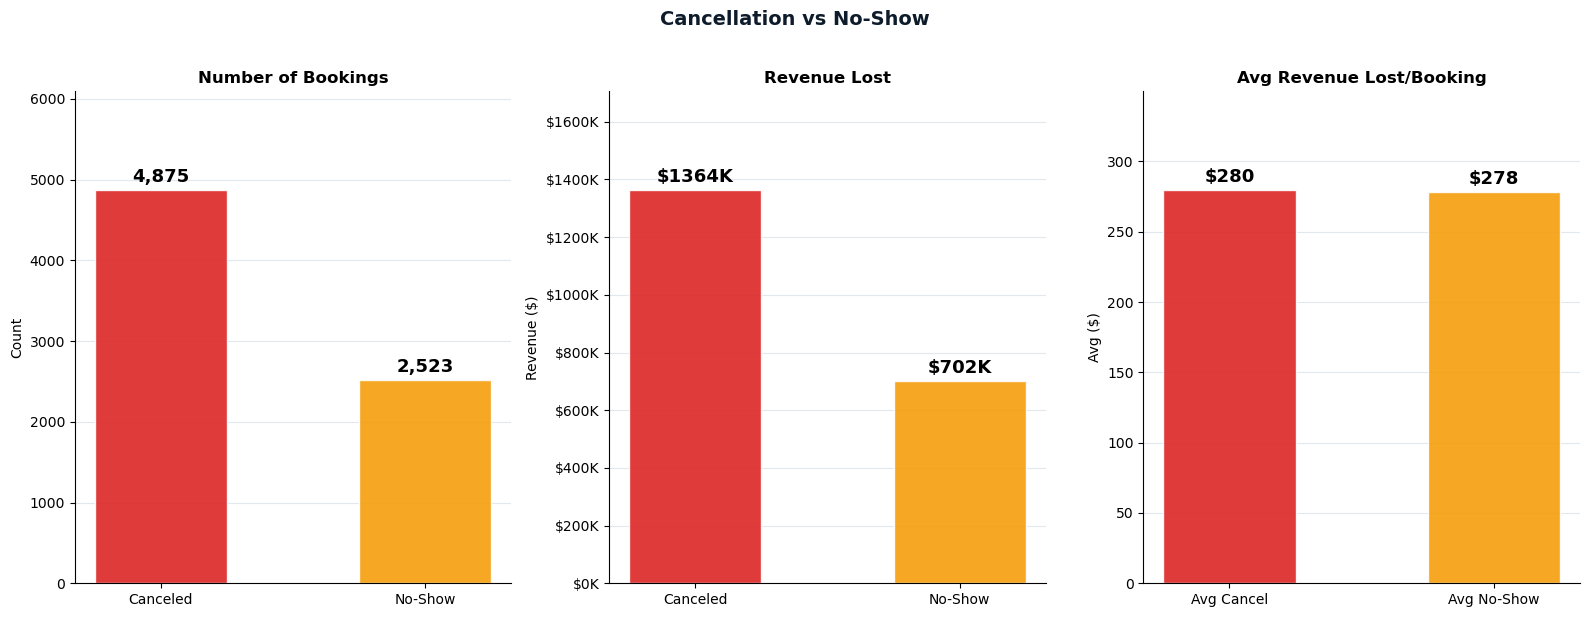

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor("#FFFFFF")
fig.suptitle("Cancellation vs No-Show", fontsize=14, fontweight="bold", color=HEADER, y=1.02)

data = [
    ([n_cancel, n_noshow],          ["Canceled","No-Show"],          "Number of Bookings",      "Count",       "{:,}",    False),
    ([cancel_rev, noshow_rev],       ["Canceled","No-Show"],          "Revenue Lost",            "Revenue ($)", "${:.0f}K", True),
    ([avg_cancel, avg_noshow],       ["Avg Cancel","Avg No-Show"],    "Avg Revenue Lost/Booking","Avg ($)",     "${:.0f}",  False),
]

for ax, (vals, labels, title, ylabel, fmt, div1k) in zip(axes, data):
    bars = ax.bar(labels, vals, color=[C_CANCEL, C_NOSHOW], edgecolor="white", width=0.5, alpha=0.9)
    for bar, v in zip(bars, vals):
        lbl = fmt.format(v/1000 if div1k else v)
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02, lbl, ha="center", fontweight="bold", fontsize=13)
    ax.set_title(title, fontweight="bold", fontsize=12); ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals)*1.25)
    ax.spines[["top","right"]].set_visible(False)
    ax.yaxis.grid(True, color="#E2E8F0"); ax.set_axisbelow(True)
    if div1k: ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"${v/1000:.0f}K"))


plt.tight_layout()
plt.show()


## 4. Monthly Revenue Loss Trends



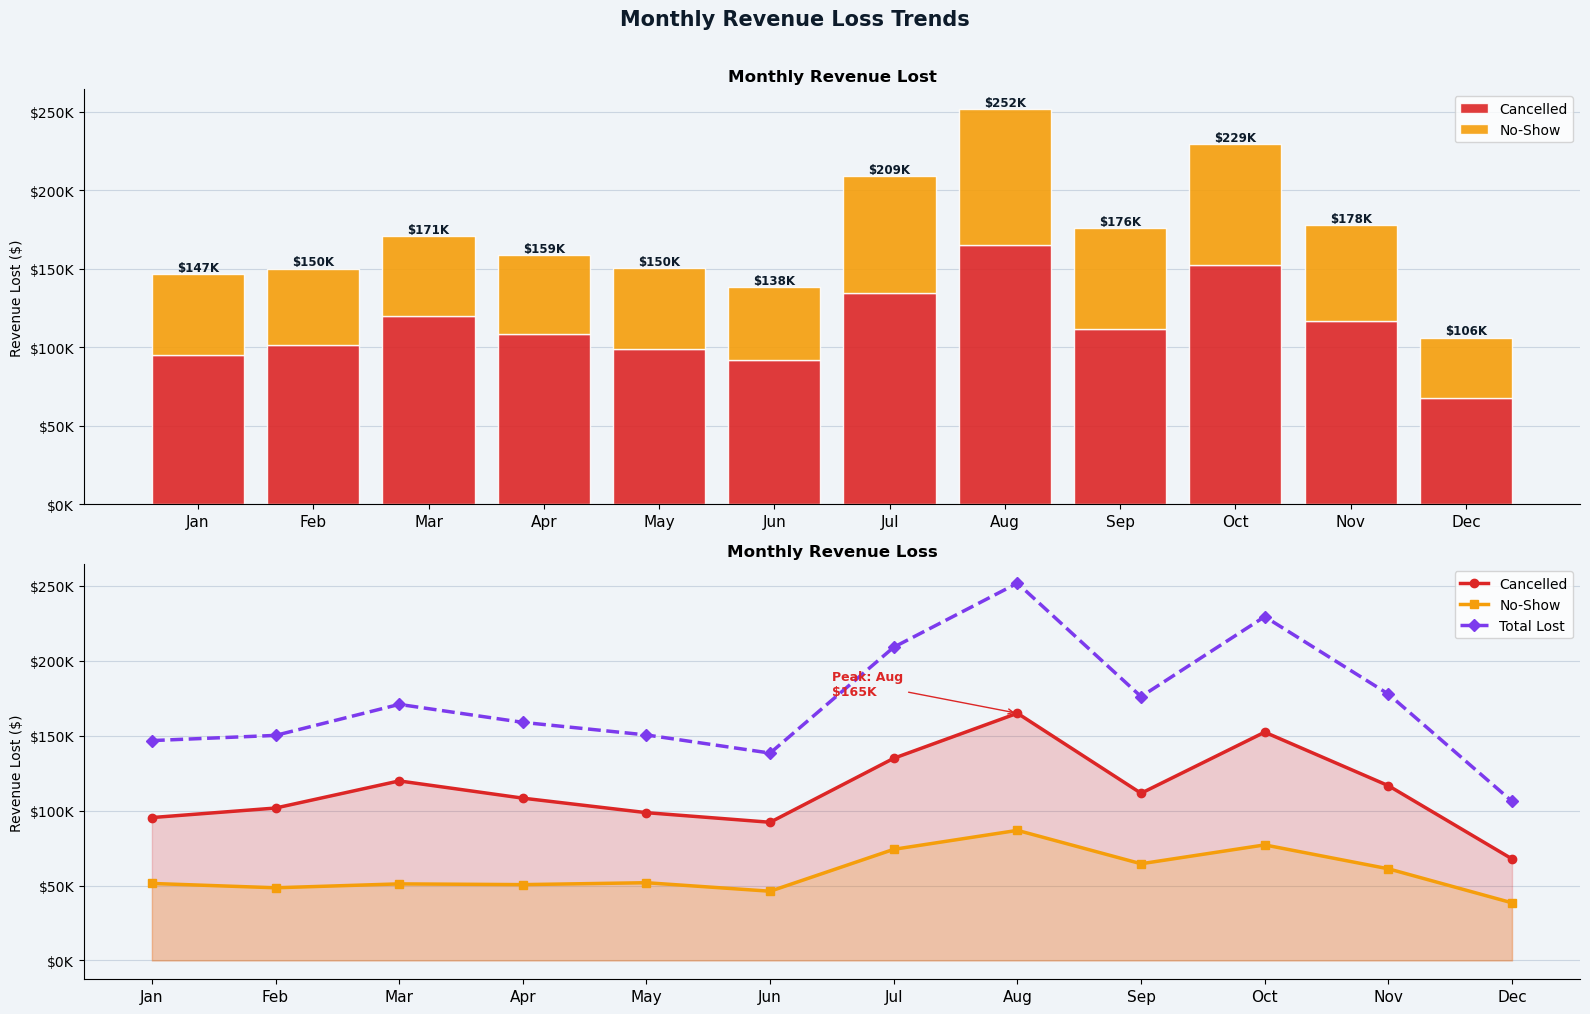

In [ ]:
monthly = (
    df[df["Reservation_Status"].isin(["Canceled","No-Show"])]
    .groupby(["Checkin_Month","Reservation_Status"])["Revenue_At_Risk"]
    .sum().unstack().fillna(0)
    .reindex(range(1,13), fill_value=0)
)
cm = monthly.get("Canceled", pd.Series([0]*12, index=range(1,13))).values
nm = monthly.get("No-Show",  pd.Series([0]*12, index=range(1,13))).values
tm = cm + nm

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor(LIGHT)
fig.suptitle("Monthly Revenue Loss Trends", fontsize=15, fontweight="bold", color=HEADER, y=1.01)

x = np.arange(12)

# ── Stacked bar 
ax1 = axes[0]; ax1.set_facecolor(LIGHT)
ax1.bar(x, cm, color=C_CANCEL, alpha=0.9, edgecolor="white", label="Cancelled")
ax1.bar(x, nm, bottom=cm, color=C_NOSHOW, alpha=0.9, edgecolor="white", label="No-Show")
for i, t in enumerate(tm): ax1.text(i, t+2000, f"${t/1000:.0f}K", ha="center", fontsize=8.5, fontweight="bold", color=HEADER)
ax1.set_xticks(x); ax1.set_xticklabels(MONTH_NAMES, fontsize=11)
ax1.set_title("Monthly Revenue Lost", fontweight="bold"); ax1.set_ylabel("Revenue Lost ($)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"${v/1000:.0f}K"))
ax1.spines[["top","right"]].set_visible(False); ax1.yaxis.grid(True, color="#CBD5E1"); ax1.set_axisbelow(True); ax1.legend(fontsize=10)

# ── Trend line ────────────────────────────────────────────
ax2 = axes[1]; ax2.set_facecolor(LIGHT)
ax2.fill_between(x, cm, alpha=0.2, color=C_CANCEL); ax2.fill_between(x, nm, alpha=0.2, color=C_NOSHOW)
ax2.plot(x, cm, color=C_CANCEL, linewidth=2.5, marker="o", markersize=6, label="Cancelled")
ax2.plot(x, nm, color=C_NOSHOW, linewidth=2.5, marker="s", markersize=6, label="No-Show")
ax2.plot(x, tm, color=C_TOTAL,  linewidth=2.5, marker="D", markersize=6, linestyle="--", label="Total Lost")
peak = int(np.argmax(cm))
ax2.annotate(f"Peak: {MONTH_NAMES[peak]}\n${cm[peak]/1000:.0f}K", xy=(peak,cm[peak]),
             xytext=(peak-1.5,cm[peak]+12000), arrowprops=dict(arrowstyle="->",color=C_CANCEL),
             fontsize=9, color=C_CANCEL, fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES, fontsize=11)
ax2.set_title("Monthly Revenue Loss", fontweight="bold"); ax2.set_ylabel("Revenue Lost ($)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"${v/1000:.0f}K"))
ax2.spines[["top","right"]].set_visible(False); ax2.yaxis.grid(True, color="#CBD5E1"); ax2.set_axisbelow(True); ax2.legend(fontsize=10)



plt.tight_layout()
plt.show()
